In [1]:
import os, glob, random
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import pandas as pd
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import jaccard_score, f1_score

import tensorflow as tf
import segmentation_models as sm

sm.set_framework('tf.keras')
sm.framework()   

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))

Segmentation Models: using `keras` framework.
TensorFlow: 2.10.1
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## PARTE 1 – Carga y Exploración de Datos 

In [2]:

DATA_DIR   = 'BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData'
IMG_SIZE   = 128
SLICE_IDX  = 80      
MODALITY   = 'T2'  
CHANNELS   = 3        
BACKBONE   = 'resnet34'
EPOCHS     = 50
BATCH_SIZE = 8
SUBSAMPLE = 0.50 


patient_dirs = sorted(glob.glob(os.path.join(DATA_DIR, 'BraTS20_Training_*')))
print(f'Total pacientes : {len(patient_dirs)}')
print(f'Ejemplo         : {patient_dirs[0]}')
print('Archivos:')
for f in sorted(os.listdir(patient_dirs[0])): print(f'  {f}')

Total pacientes : 369
Ejemplo         : BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData\BraTS20_Training_001
Archivos:
  BraTS20_Training_001_flair.nii
  BraTS20_Training_001_seg.nii
  BraTS20_Training_001_t1.nii
  BraTS20_Training_001_t1ce.nii
  BraTS20_Training_001_t2.nii


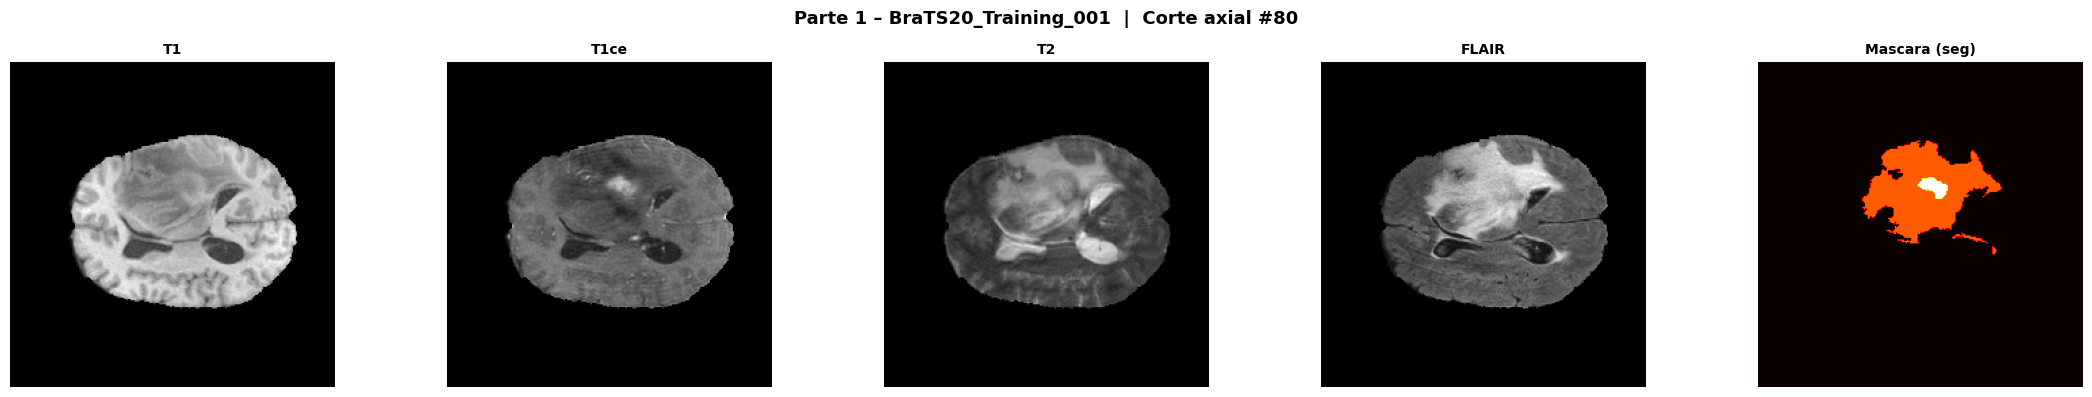

In [3]:
def load_nii_slice(patient_dir, suffix, slice_idx=SLICE_IDX):
    pid  = os.path.basename(patient_dir)
    path = os.path.join(patient_dir, f'{pid}_{suffix}.nii')
    vol  = nib.load(path).get_fdata() 
    return vol[:, :, slice_idx]
ex_dir     = patient_dirs[0]
modalities = ['t1', 't1ce', 't2', 'flair']
labels     = ['T1', 'T1ce', 'T2', 'FLAIR']

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for i, (mod, lbl) in enumerate(zip(modalities, labels)):
    axes[i].imshow(load_nii_slice(ex_dir, mod), cmap='gray')
    axes[i].set_title(lbl, fontsize=10, fontweight='bold')
    axes[i].axis('off')

axes[4].imshow(load_nii_slice(ex_dir, 'seg'), cmap='hot')
axes[4].set_title('Mascara (seg)', fontsize=10, fontweight='bold')
axes[4].axis('off')

plt.suptitle(f'Parte 1 – {os.path.basename(ex_dir)}  |  Corte axial #{SLICE_IDX}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('parte1_modalidades.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:

t1ce = load_nii_slice(ex_dir, 'T2')
seg  = load_nii_slice(ex_dir, 'seg')
mask = (seg > 0).astype(np.float32)



In [5]:
total    = len(patient_dirs)
n_sample = int(total * SUBSAMPLE)

random.seed(SEED)
sampled_dirs = random.sample(patient_dirs, n_sample)

print('Submuestreo')
print(f'  Pacientes totales  : {total}')
print(f'  Fraccion utilizada : {SUBSAMPLE*100:.0f}%')
print(f'  Pacientes en uso   : {n_sample}')

Submuestreo
  Pacientes totales  : 369
  Fraccion utilizada : 50%
  Pacientes en uso   : 184


## PARTE 3 – Preprocesamiento

In [ ]:
preprocess_input = sm.get_preprocessing('resnet34')

SLICE_RANGE   = range(60, 100, 5)   
MIN_TUMOR_PCT = 0.005           

def preprocess_sample(patient_dir, modality=MODALITY, img_size=IMG_SIZE,
                      slice_idx=SLICE_IDX, channels=CHANNELS):
    pid = os.path.basename(patient_dir)

    img_vol = nib.load(os.path.join(patient_dir, f'{pid}_{modality}.nii')).get_fdata()
    sl = img_vol[:, :, slice_idx].astype(np.float32)
    sl = cv2.resize(sl, (img_size, img_size), interpolation=cv2.INTER_LINEAR)
    img = np.stack([sl] * channels, axis=-1)
    img = preprocess_input(img)  

    seg_vol = nib.load(os.path.join(patient_dir, f'{pid}_seg.nii')).get_fdata()
    seg_sl  = (seg_vol[:, :, slice_idx] > 0).astype(np.float32)
    seg_sl  = cv2.resize(seg_sl, (img_size, img_size), interpolation=cv2.INTER_NEAREST)
    mask    = seg_sl[..., np.newaxis]
    return img, mask


print(f'Cargando {n_sample} pacientes × {len(list(SLICE_RANGE))} slices (filtrando vacios)...')
X_all, y_all = [], []
for i, pdir in enumerate(sampled_dirs):
    for s_idx in SLICE_RANGE:
        try:
            img, mask = preprocess_sample(pdir, slice_idx=s_idx)
          
            if mask.mean() >= MIN_TUMOR_PCT:
                X_all.append(img)
                y_all.append(mask)
        except Exception:
            pass
    if (i+1) % 20 == 0:
        print(f'  {i+1}/{n_sample} pacientes... (muestras válidas: {len(X_all)})')

X_all = np.array(X_all, dtype=np.float32)
y_all = np.array(y_all, dtype=np.float32)

print(f'\nX_all: {X_all.shape}  y_all: {y_all.shape}')
print(f'Rango  : [{X_all.min():.3f}, {X_all.max():.3f}]')
print(f'% tumor: {100*y_all.mean():.2f}%')

X_train, X_temp, y_train, y_temp = train_test_split(X_all, y_all, test_size=0.30, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED)

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_val  : {X_val.shape}, y_val  : {y_val.shape}')
print(f'X_test : {X_test.shape}, y_test : {y_test.shape}')

Cargando 184 pacientes × 8 slices (filtrando vacios)...
  20/184 pacientes... (muestras válidas: 117)
  40/184 pacientes... (muestras válidas: 233)
  60/184 pacientes... (muestras válidas: 345)
  80/184 pacientes... (muestras válidas: 471)
  100/184 pacientes... (muestras válidas: 612)
  120/184 pacientes... (muestras válidas: 719)
  140/184 pacientes... (muestras válidas: 845)
  160/184 pacientes... (muestras válidas: 963)
  180/184 pacientes... (muestras válidas: 1087)

X_all: (1112, 128, 128, 3)  y_all: (1112, 128, 128, 1)
Rango  : [0.000, 31754.215]
% tumor: 3.62%
X_train: (778, 128, 128, 3), y_train: (778, 128, 128, 1)
X_val  : (167, 128, 128, 3), y_val  : (167, 128, 128, 1)
X_test : (167, 128, 128, 3), y_test : (167, 128, 128, 1)


## PARTE 4 – Implementación de Modelos (55%)

In [7]:
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def dice_coef(y_true, y_pred, smooth=1e-6):
    y_t = K.flatten(y_true); y_p = K.flatten(y_pred)
    return (2.*K.sum(y_t*y_p)+smooth) / (K.sum(y_t)+K.sum(y_p)+smooth)

def dice_loss(y_true, y_pred): return 1.0 - dice_coef(y_true, y_pred)


def bce_dice_loss(y_true, y_pred):
    return tf.keras.losses.binary_crossentropy(y_true, y_pred) + dice_loss(y_true, y_pred)

def iou_metric(y_true, y_pred, smooth=1e-6):
    y_t = K.flatten(y_true); y_p = K.flatten(tf.round(y_pred))
    inter = K.sum(y_t*y_p)
    return (inter+smooth) / (K.sum(y_t)+K.sum(y_p)-inter+smooth)

def get_callbacks(name):
    return [
        tf.keras.callbacks.ModelCheckpoint(f'{name}_best.h5', monitor='val_dice_coef',
                                           save_best_only=True, mode='max', verbose=1,save_weights_only=True),
        tf.keras.callbacks.EarlyStopping(monitor='val_dice_coef', patience=15,
                                         mode='max', restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                             patience=5, min_lr=1e-7, verbose=1)
    ]


_aug_args = dict(rotation_range=15, width_shift_range=0.1, height_shift_range=0.1,
                 horizontal_flip=True, zoom_range=0.1, fill_mode='reflect')
_img_gen  = ImageDataGenerator(**_aug_args)
_mask_gen = ImageDataGenerator(**_aug_args)

def make_aug_gen(X, y, batch_size=BATCH_SIZE):
    ig = _img_gen.flow(X,  batch_size=batch_size, seed=SEED)
    mg = _mask_gen.flow(y, batch_size=batch_size, seed=SEED)
    return zip(ig, mg)

STEPS = len(X_train) // BATCH_SIZE


COMPILE = dict(
    optimizer=tf.keras.optimizers.Adam(3e-4),
    loss=bce_dice_loss,          # ← clave para evitar máscaras de un solo color
    metrics=[iou_metric, dice_coef]
)

FIT = dict(x=X_train, y=y_train, validation_data=(X_val, y_val),
           epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=1)

histories = {}
print('Configuracion lista. Loss: BCE + Dice | LR: 3e-4 | Augmentation: ON')


Configuracion lista. Loss: BCE + Dice | LR: 3e-4 | Augmentation: ON


 # U-Net


In [8]:
tf.keras.backend.clear_session()
print('='*50, '\nMODELO 1: U-Net\n', '='*50)
model_unet = sm.Unet(BACKBONE, input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS),
                     classes=1, activation='sigmoid',
                     encoder_weights='imagenet', encoder_freeze=False)
model_unet.compile(**COMPILE)
print(f'Parametros: {model_unet.count_params():,}')

hist_unet = model_unet.fit(
    make_aug_gen(X_train, y_train),
    steps_per_epoch=STEPS,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    callbacks=get_callbacks('unet'),
    verbose=1
)
histories['U-Net'] = hist_unet
print('U-Net entrenado.')


MODELO 1: U-Net
Parametros: 24,456,154
Epoch 1/50
97/97 [==============================] - ETA: 0s - loss: 0.9551 - iou_metric: 0.3656 - dice_coef: 0.2607
Epoch 1: val_dice_coef improved from -inf to 0.25447, saving model to unet_best.h5
97/97 [==============================] - 15s 85ms/step - loss: 0.9551 - iou_metric: 0.3656 - dice_coef: 0.2607 - val_loss: 0.9850 - val_iou_metric: 0.3617 - val_dice_coef: 0.2545 - lr: 3.0000e-04
Epoch 2/50
97/97 [==============================] - ETA: 0s - loss: 0.4717 - iou_metric: 0.5978 - dice_coef: 0.5920
Epoch 2: val_dice_coef improved from 0.25447 to 0.57105, saving model to unet_best.h5
97/97 [==============================] - 7s 73ms/step - loss: 0.4717 - iou_metric: 0.5978 - dice_coef: 0.5920 - val_loss: 0.5260 - val_iou_metric: 0.5049 - val_dice_coef: 0.5710 - lr: 3.0000e-04
Epoch 3/50
97/97 [==============================] - ETA: 0s - loss: 0.3290 - iou_metric: 0.6491 - dice_coef: 0.7238
Epoch 3: val_dice_coef improved from 0.57105 to 0.677

# MODELO 2: FPN


In [9]:
tf.keras.backend.clear_session()

print('='*50, '\nMODELO 2: FPN\n', '='*50)
model_fpn = sm.FPN(BACKBONE, input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS),
                   classes=1, activation='sigmoid',
                   encoder_weights='imagenet', encoder_freeze=False)
model_fpn.compile(**COMPILE)
print(f'Parametros: {model_fpn.count_params():,}')

hist_fpn = model_fpn.fit(
    make_aug_gen(X_train, y_train),
    steps_per_epoch=STEPS,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    callbacks=get_callbacks('fpn'),
    verbose=1
)
histories['FPN'] = hist_fpn
print('FPN entrenado.')


MODELO 2: FPN
Parametros: 23,930,954
Epoch 1/50
97/97 [==============================] - ETA: 0s - loss: 1.2117 - iou_metric: 0.2028 - dice_coef: 0.1506
Epoch 1: val_dice_coef improved from -inf to 0.10736, saving model to fpn_best.h5
97/97 [==============================] - 20s 147ms/step - loss: 1.2117 - iou_metric: 0.2028 - dice_coef: 0.1506 - val_loss: 1.1566 - val_iou_metric: 0.2025 - val_dice_coef: 0.1074 - lr: 9.3750e-06
Epoch 2/50
97/97 [==============================] - ETA: 0s - loss: 0.8339 - iou_metric: 0.3894 - dice_coef: 0.3098
Epoch 2: val_dice_coef improved from 0.10736 to 0.28900, saving model to fpn_best.h5
97/97 [==============================] - 13s 130ms/step - loss: 0.8339 - iou_metric: 0.3894 - dice_coef: 0.3098 - val_loss: 0.8498 - val_iou_metric: 0.4120 - val_dice_coef: 0.2890 - lr: 9.3750e-06
Epoch 3/50
97/97 [==============================] - ETA: 0s - loss: 0.6258 - iou_metric: 0.5051 - dice_coef: 0.4639
Epoch 3: val_dice_coef improved from 0.28900 to 0.4307

#  MODELO 3: LinkNet 


In [10]:
tf.keras.backend.clear_session()

print('='*50, '\nMODELO 3: LinkNet\n', '='*50)
model_linknet = sm.Linknet(BACKBONE, input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS),
                           classes=1, activation='sigmoid',
                           encoder_weights='imagenet', encoder_freeze=False)
model_linknet.compile(**COMPILE)
print(f'Parametros: {model_linknet.count_params():,}')

hist_linknet = model_linknet.fit(
    make_aug_gen(X_train, y_train),
    steps_per_epoch=STEPS,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    callbacks=get_callbacks('linknet'),
    verbose=1
)
histories['LinkNet'] = hist_linknet
print('LinkNet entrenado.')


MODELO 3: LinkNet
Parametros: 21,637,274
Epoch 1/50
97/97 [==============================] - ETA: 0s - loss: 1.7034 - iou_metric: 0.0435 - dice_coef: 0.0763
Epoch 1: val_dice_coef improved from -inf to 0.08976, saving model to linknet_best.h5
97/97 [==============================] - 10s 67ms/step - loss: 1.7034 - iou_metric: 0.0435 - dice_coef: 0.0763 - val_loss: 1.8289 - val_iou_metric: 0.0452 - val_dice_coef: 0.0898 - lr: 9.3750e-06
Epoch 2/50
97/97 [==============================] - ETA: 0s - loss: 1.5612 - iou_metric: 0.0768 - dice_coef: 0.0868
Epoch 2: val_dice_coef did not improve from 0.08976
97/97 [==============================] - 6s 57ms/step - loss: 1.5612 - iou_metric: 0.0768 - dice_coef: 0.0868 - val_loss: 1.6334 - val_iou_metric: 0.0766 - val_dice_coef: 0.0866 - lr: 9.3750e-06
Epoch 3/50
97/97 [==============================] - ETA: 0s - loss: 1.4766 - iou_metric: 0.1375 - dice_coef: 0.0966
Epoch 3: val_dice_coef improved from 0.08976 to 0.09124, saving model to linknet_b

#  MODELO 4: PSPNet 


In [11]:
tf.keras.backend.clear_session()

print('='*50, '\nMODELO 4: PSPNet (96x96)\n', '='*50)

PSP_SIZE = 96

def resize_psp(X, y, s=PSP_SIZE):
    Xr = np.array([cv2.resize(x,(s,s)) for x in X], dtype=np.float32)
    yr = np.array([cv2.resize(m[:,:,0],(s,s),
                              interpolation=cv2.INTER_NEAREST)[...,np.newaxis]
                   for m in y], dtype=np.float32)
    return Xr, yr

X_trp, y_trp = resize_psp(X_train, y_train)
X_vlp, y_vlp = resize_psp(X_val,   y_val)
X_tsp, y_tsp = resize_psp(X_test,  y_test)

model_pspnet = sm.PSPNet(BACKBONE, input_shape=(PSP_SIZE, PSP_SIZE, CHANNELS),
                         classes=1, activation='sigmoid',
                         encoder_weights='imagenet', encoder_freeze=False)
model_pspnet.compile(**COMPILE)
print(f'Parametros: {model_pspnet.count_params():,}')

STEPS_PSP = len(X_trp) // BATCH_SIZE

hist_pspnet = model_pspnet.fit(
    make_aug_gen(X_trp, y_trp),
    steps_per_epoch=STEPS_PSP,
    validation_data=(X_vlp, y_vlp),
    epochs=EPOCHS,
    callbacks=get_callbacks('pspnet'),
    verbose=1
)
histories['PSPNet'] = hist_pspnet
print('PSPNet entrenado.')


MODELO 4: PSPNet (96x96)
Parametros: 2,746,058
Epoch 1/50
97/97 [==============================] - ETA: 0s - loss: 0.8519 - iou_metric: 0.3353 - dice_coef: 0.3145
Epoch 1: val_dice_coef improved from -inf to 0.12566, saving model to pspnet_best.h5
97/97 [==============================] - 4s 24ms/step - loss: 0.8519 - iou_metric: 0.3353 - dice_coef: 0.3145 - val_loss: 1.1363 - val_iou_metric: 0.3024 - val_dice_coef: 0.1257 - lr: 9.3750e-06
Epoch 2/50
95/97 [============================>.] - ETA: 0s - loss: 0.4902 - iou_metric: 0.5157 - dice_coef: 0.5663
Epoch 2: val_dice_coef improved from 0.12566 to 0.29976, saving model to pspnet_best.h5
97/97 [==============================] - 2s 20ms/step - loss: 0.4902 - iou_metric: 0.5150 - dice_coef: 0.5662 - val_loss: 0.8029 - val_iou_metric: 0.4576 - val_dice_coef: 0.2998 - lr: 9.3750e-06
Epoch 3/50
95/97 [============================>.] - ETA: 0s - loss: 0.4158 - iou_metric: 0.5551 - dice_coef: 0.6382
Epoch 3: val_dice_coef improved from 0.299

# Curvas de entrenamiento

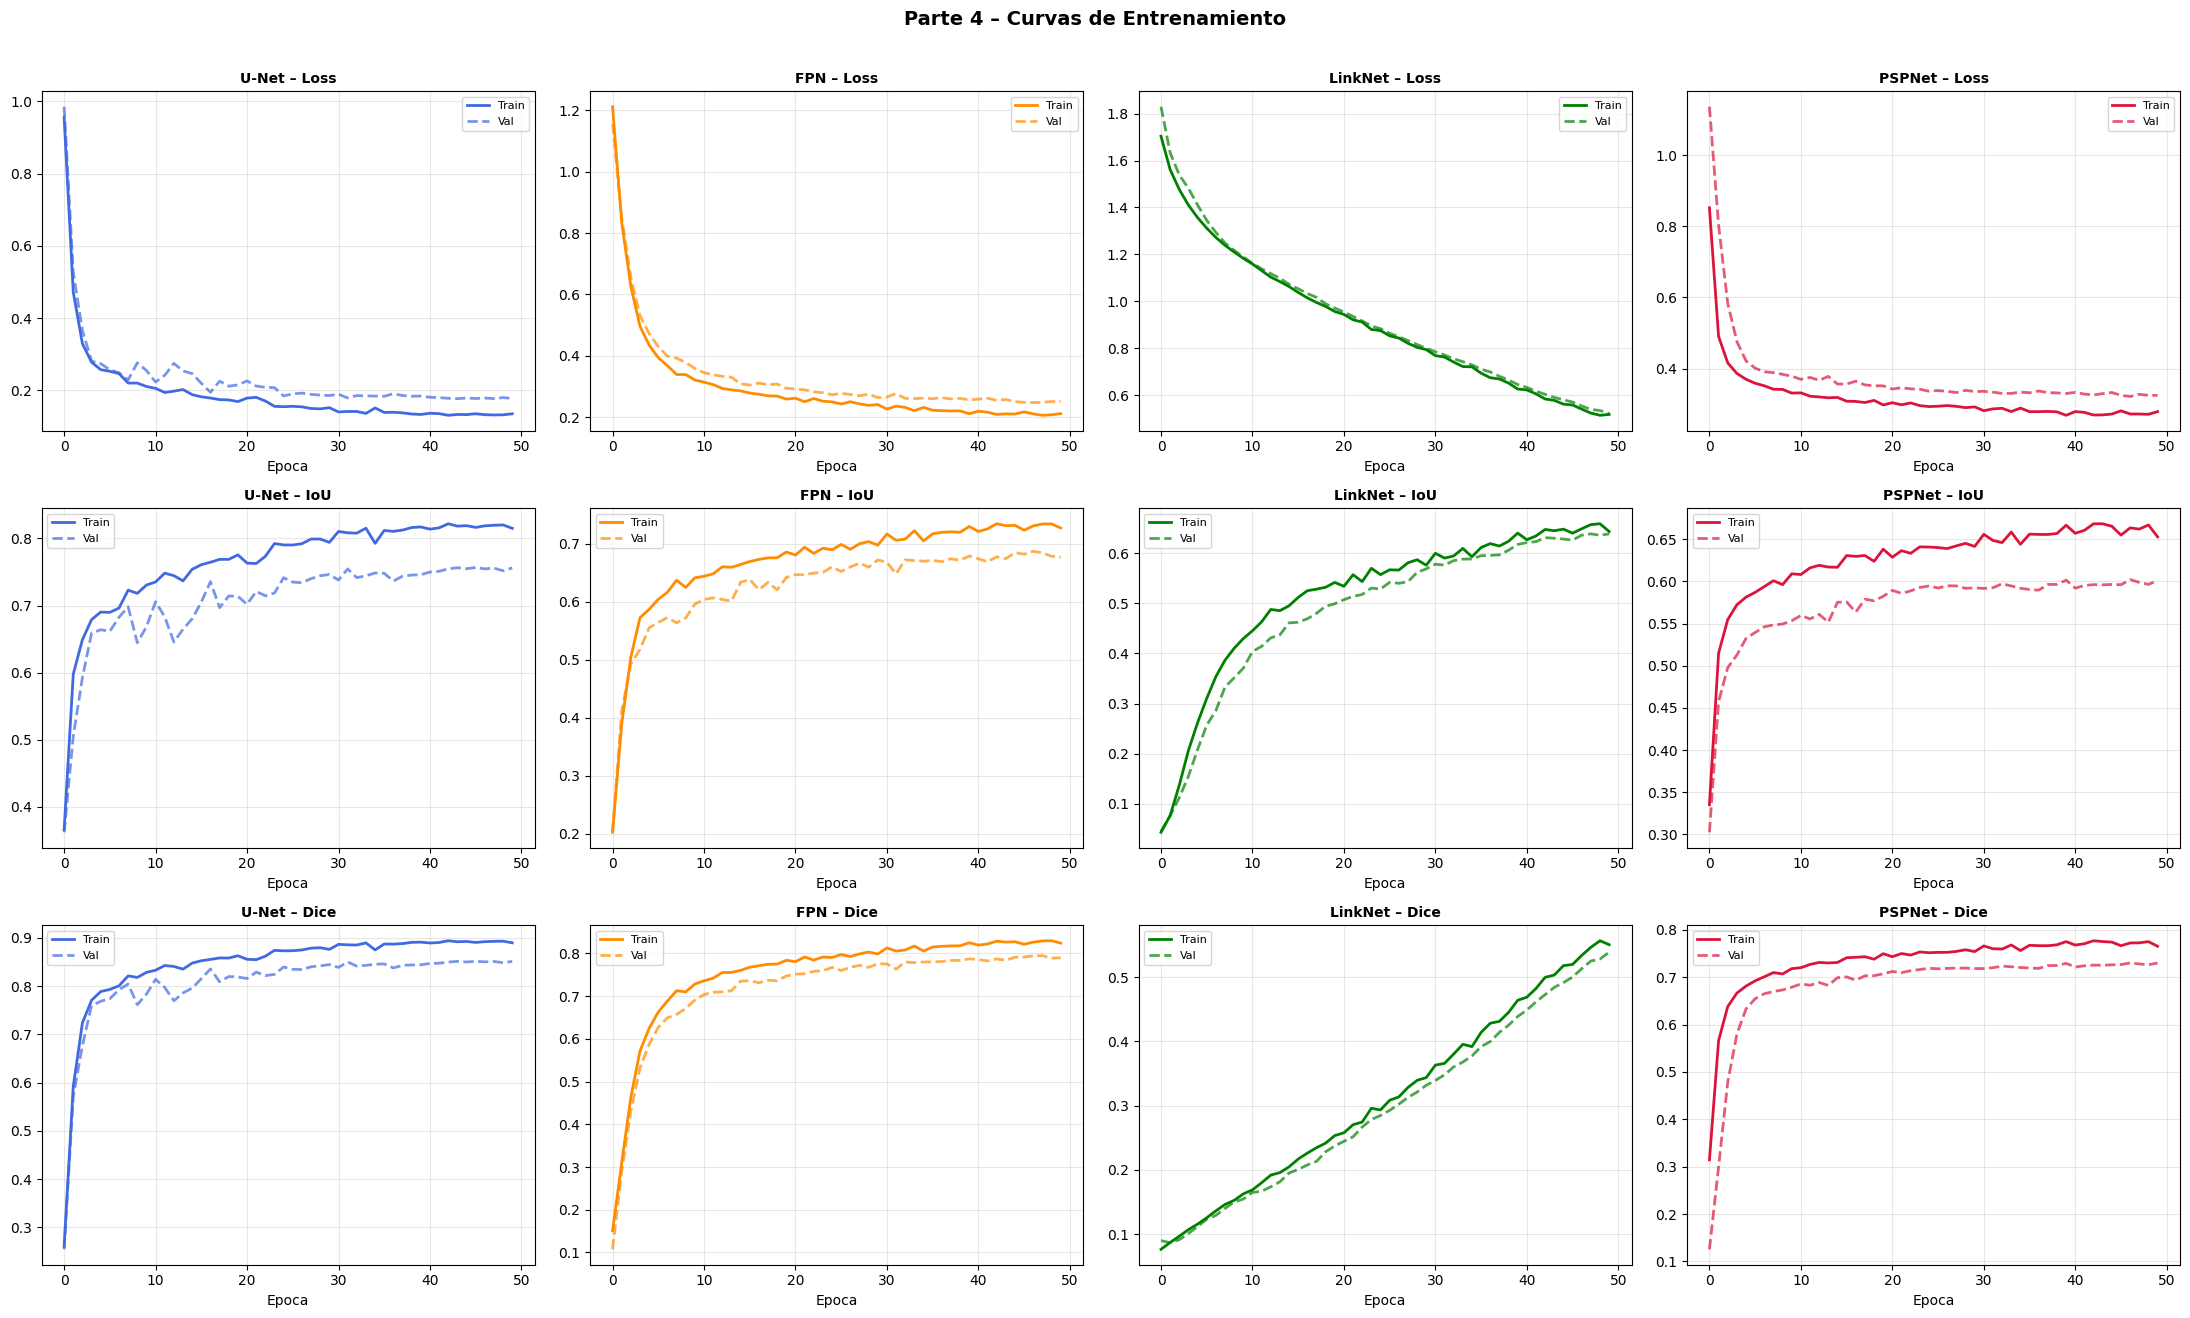

In [12]:

cols    = ['U-Net','FPN','LinkNet','PSPNet']
colors  = ['royalblue','darkorange','green','crimson']
met_cfg = [('loss','val_loss','Loss'), ('iou_metric','val_iou_metric','IoU'),
           ('dice_coef','val_dice_coef','Dice')]

fig, axes = plt.subplots(3, 4, figsize=(22, 13))
for c, (name, col) in enumerate(zip(cols, colors)):
    h = histories[name].history
    for r, (tk, vk, lbl) in enumerate(met_cfg):
        ax = axes[r, c]
        ax.plot(h.get(tk,[]),  label='Train', lw=2, color=col)
        ax.plot(h.get(vk,[]),  label='Val',   lw=2, color=col, ls='--', alpha=0.7)
        ax.set_title(f'{name} – {lbl}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Epoca'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle('Parte 4 – Curvas de Entrenamiento', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('parte4_curvas.png', dpi=150, bbox_inches='tight')
plt.show()

---
## PARTE 5 – Evaluación (10%)

In [13]:
import gc

def clear_gpu():
    tf.keras.backend.clear_session()
    gc.collect()

# 1. U-Net
print("Prediciendo con U-Net...")
p_unet = model_unet.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
p_unet_tr = model_unet.predict(X_train, batch_size=BATCH_SIZE, verbose=1)
p_unet_vl = model_unet.predict(X_val, batch_size=BATCH_SIZE, verbose=1)
del model_unet
clear_gpu()

# 2. FPN
print("Prediciendo con FPN...")
p_fpn = model_fpn.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
p_fpn_tr = model_fpn.predict(X_train, batch_size=BATCH_SIZE, verbose=1)
p_fpn_vl = model_fpn.predict(X_val, batch_size=BATCH_SIZE, verbose=1)
del model_fpn
clear_gpu()

# 3. LinkNet
print("Prediciendo con LinkNet...")
p_linknet = model_linknet.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
p_lnk_tr = model_linknet.predict(X_train, batch_size=BATCH_SIZE, verbose=1)
p_lnk_vl = model_linknet.predict(X_val, batch_size=BATCH_SIZE, verbose=1)
del model_linknet
clear_gpu()

# 4. PSPNet
print("Prediciendo con PSPNet...")
p_psp_raw = model_pspnet.predict(X_tsp, batch_size=BATCH_SIZE, verbose=1)
p_psp_tr_raw = model_pspnet.predict(X_trp, batch_size=BATCH_SIZE, verbose=1)
p_psp_vl_raw = model_pspnet.predict(X_vlp, batch_size=BATCH_SIZE, verbose=1)
del model_pspnet
clear_gpu()

p_pspnet = np.array([cv2.resize(p[:,:,0],(IMG_SIZE,IMG_SIZE))[...,np.newaxis]
                     for p in p_psp_raw], dtype=np.float32)
p_psp_tr = np.array([cv2.resize(p[:,:,0],(IMG_SIZE,IMG_SIZE))[...,np.newaxis]
                     for p in p_psp_tr_raw], dtype=np.float32)
p_psp_vl = np.array([cv2.resize(p[:,:,0],(IMG_SIZE,IMG_SIZE))[...,np.newaxis]
                     for p in p_psp_vl_raw], dtype=np.float32)

def metrics_np(y_true, y_pred_prob, thr=0.5):
    yp = (y_pred_prob > thr).astype(np.uint8).flatten()
    yt = y_true.astype(np.uint8).flatten()
    return jaccard_score(yt, yp, zero_division=0), f1_score(yt, yp, zero_division=0)

test_preds  = {'U-Net': p_unet,    'FPN': p_fpn,    'LinkNet': p_linknet, 'PSPNet': p_pspnet}
train_preds = {'U-Net': p_unet_tr, 'FPN': p_fpn_tr, 'LinkNet': p_lnk_tr,  'PSPNet': p_psp_tr}
val_preds   = {'U-Net': p_unet_vl, 'FPN': p_fpn_vl, 'LinkNet': p_lnk_vl,  'PSPNet': p_psp_vl}

rows = []
for name in ['U-Net','FPN','LinkNet','PSPNet']:
    iou_tr,  dice_tr  = metrics_np(y_train, train_preds[name])
    iou_vl,  dice_vl  = metrics_np(y_val,   val_preds[name])
    iou_ts,  dice_ts  = metrics_np(y_test,  test_preds[name])
    rows.append({'Modelo': name,
                 'Train IoU': round(iou_tr,4), 'Train Dice': round(dice_tr,4),
                 'Val IoU':   round(iou_vl,4), 'Val Dice':   round(dice_vl,4),
                 'Test IoU':  round(iou_ts,4), 'Test Dice':  round(dice_ts,4)})

df_results = pd.DataFrame(rows).set_index('Modelo').sort_values('Test Dice', ascending=False)
df_results['Ranking'] = range(1, 5)

print('\n' + '='*70)
print('  RESULTADOS: TRAIN / VALIDACION / TEST')
print('='*70)
print(df_results.to_string())
print('='*70)


Prediciendo con U-Net...
21/21 [==============================] - 0s 19ms/step
Prediciendo con FPN...
21/21 [==============================] - 1s 41ms/step
Prediciendo con LinkNet...
21/21 [==============================] - 0s 14ms/step
Prediciendo con PSPNet...
21/21 [==============================] - 0s 5ms/step

  RESULTADOS: TRAIN / VALIDACION / TEST
         Train IoU  Train Dice  Val IoU  Val Dice  Test IoU  Test Dice  Ranking
Modelo                                                                         
U-Net       0.8244      0.9037   0.7710    0.8707    0.7959     0.8864        1
FPN         0.7323      0.8454   0.6911    0.8173    0.7150     0.8338        2
LinkNet     0.6821      0.8110   0.6469    0.7856    0.6623     0.7968        3
PSPNet      0.6685      0.8013   0.6206    0.7659    0.6620     0.7966        4


---
## PARTE 6 – Visualización de Resultados (10%)

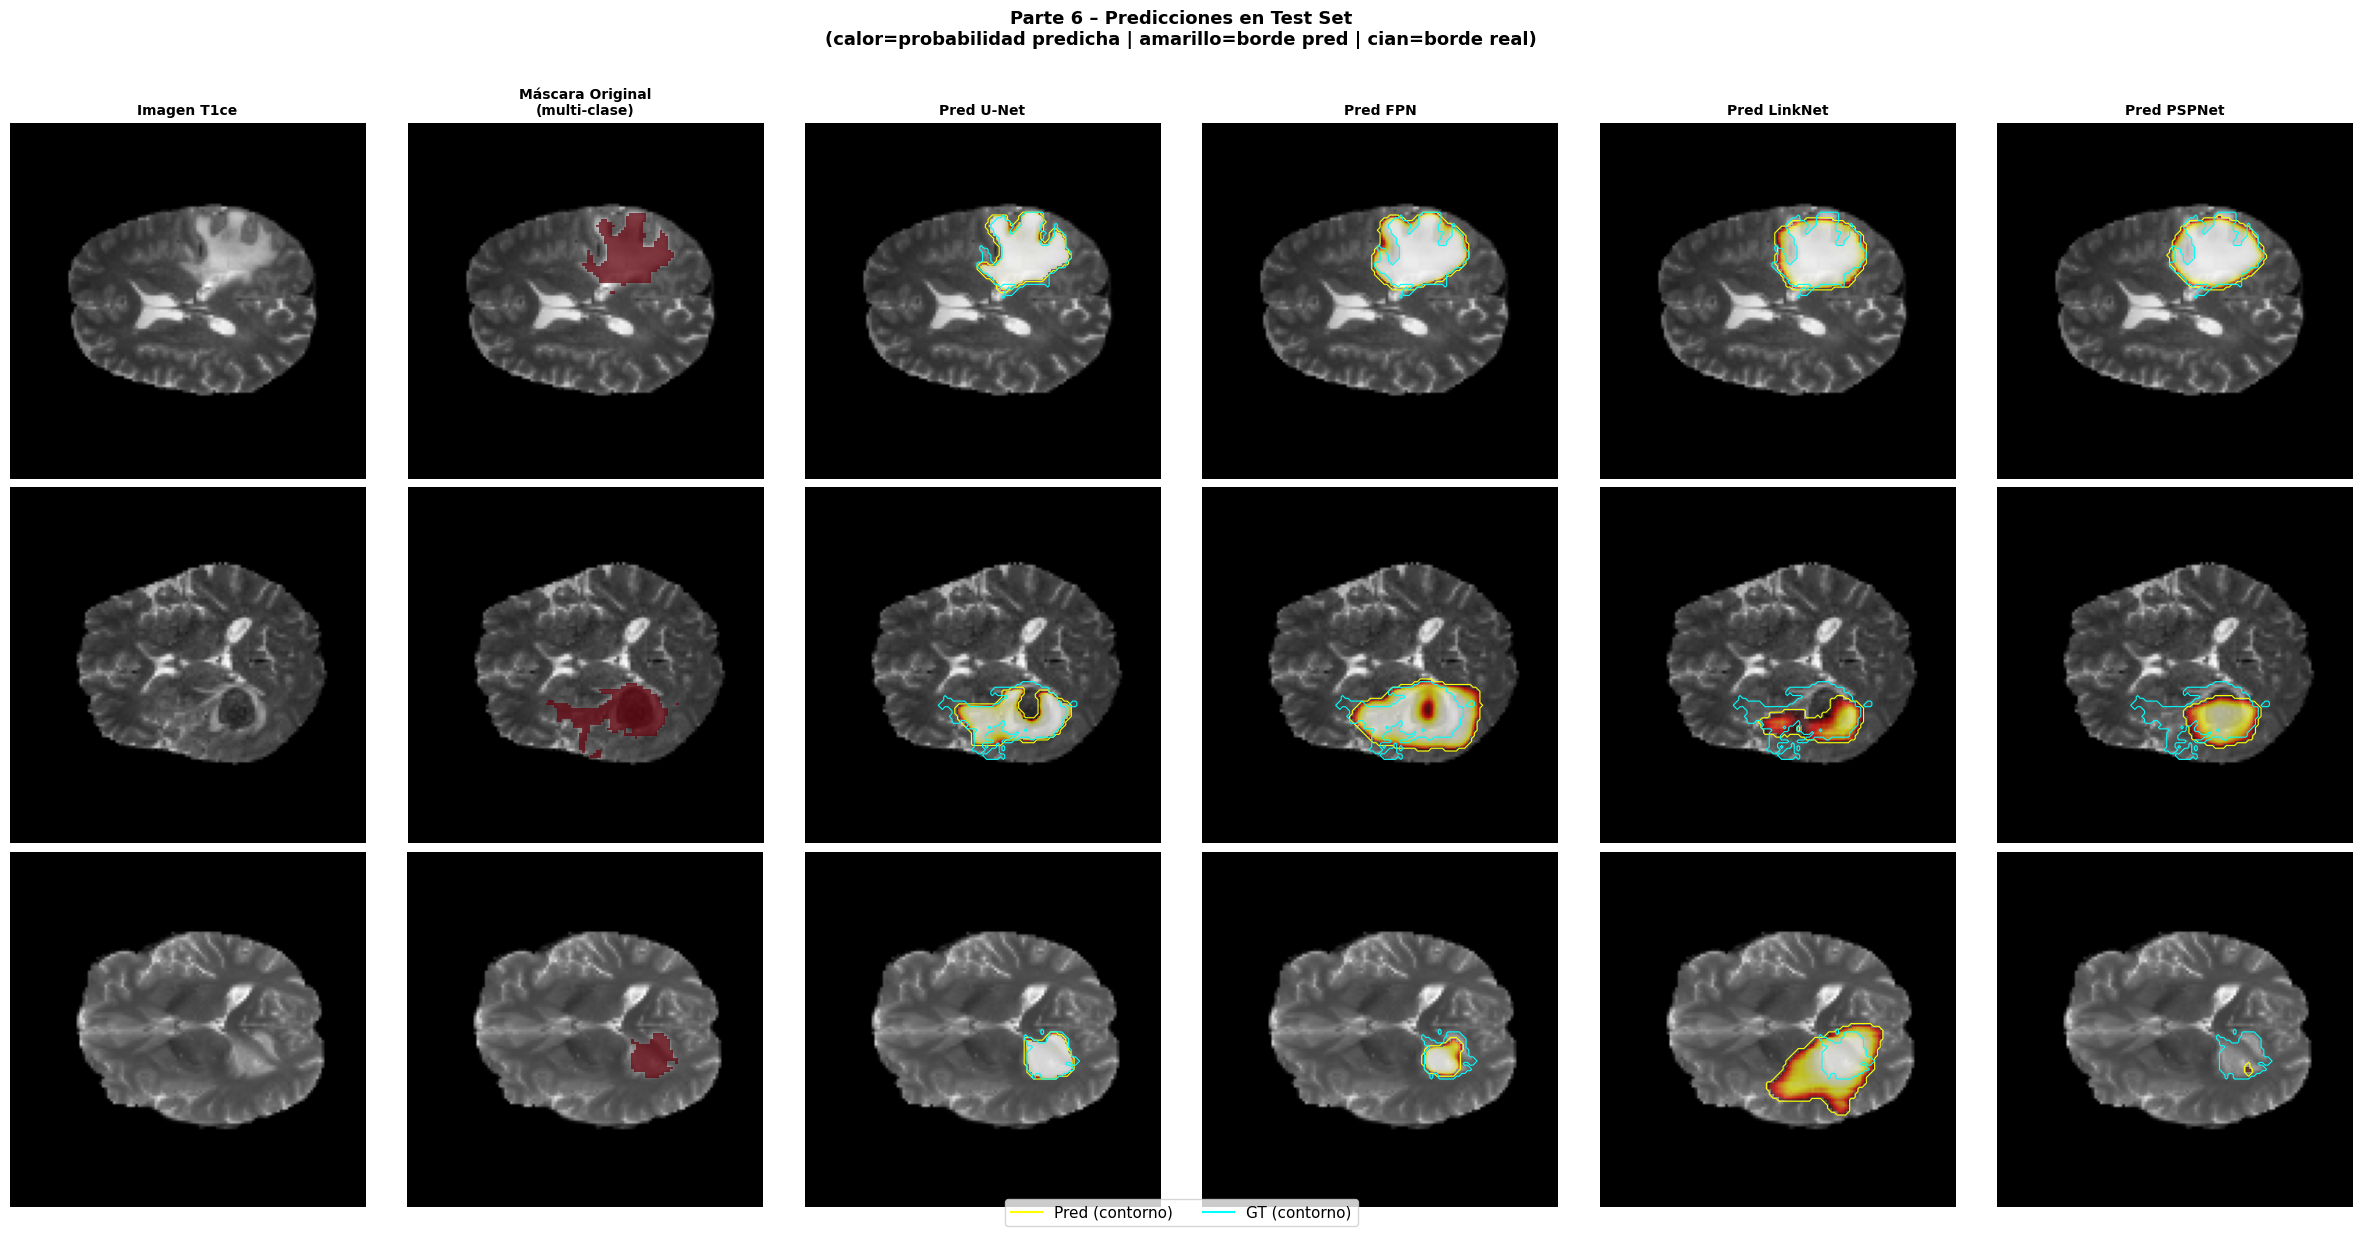

In [14]:



def load_multiclass_mask(patient_dir, img_size=IMG_SIZE, slice_idx=SLICE_IDX):
    pid = os.path.basename(patient_dir)
    seg_vol = nib.load(os.path.join(patient_dir, f'{pid}_seg.nii')).get_fdata()
    seg_sl  = seg_vol[:, :, slice_idx].astype(np.float32)
    seg_sl  = cv2.resize(seg_sl, (img_size, img_size), interpolation=cv2.INTER_NEAREST)
    return seg_sl

# Identificar pacientes del test set

import math
test_patient_idx = []
for pdir in sampled_dirs:
    for s_idx in SLICE_RANGE:
        try:
            _, m = preprocess_sample(pdir, slice_idx=s_idx)
            if m.mean() >= MIN_TUMOR_PCT:
                test_patient_idx.append((pdir, s_idx))
        except:
            pass

# Reconstruir índices del test set
all_idx  = list(range(len(test_patient_idx)))
_, temp_idx = train_test_split(all_idx, test_size=0.30, random_state=SEED)
_, t_idx    = train_test_split(temp_idx, test_size=0.50, random_state=SEED)

n_samples   = 3
col_headers = ['Imagen T1ce', 'Máscara Original\n(multi-clase)',
               'Pred U-Net', 'Pred FPN', 'Pred LinkNet', 'Pred PSPNet']
idx_list    = np.linspace(0, len(X_test)-1, n_samples, dtype=int)

# Colormap para las 3 regiones tumorales
from matplotlib.colors import ListedColormap
tumor_cmap = ListedColormap(['none','#FFD700','#FF6B35','#E63946']) 

fig, axes = plt.subplots(n_samples, 6, figsize=(4*6, 4*n_samples))
for row, idx in enumerate(idx_list):
    # Columna 0: imagen T1ce
    axes[row, 0].imshow(X_test[idx,:,:,0], cmap='gray'); axes[row,0].axis('off')

    # Columna 1: máscara original multi-clase
    # Mostrar máscara binaria coloreada sobre la imagen (ya que y_test es binaria)
    axes[row, 1].imshow(X_test[idx,:,:,0], cmap='gray')
    mc = y_test[idx,:,:,0]   # binaria
    masked_mc = np.ma.masked_where(mc == 0, mc)
    axes[row, 1].imshow(masked_mc, cmap='Reds', alpha=0.7, vmin=0, vmax=1)
    axes[row, 1].axis('off')

    # Columnas 2–5: predicciones con contorno y color degradado (probabilidad)
    for c, (mname, pred) in enumerate(test_preds.items()):
        prob = pred[idx,:,:,0]                          # probabilidad [0,1]
        pbin = (prob > 0.5).astype(np.float32)          # máscara binaria
        axes[row, 2+c].imshow(X_test[idx,:,:,0], cmap='gray')
        masked_pred = np.ma.masked_where(pbin == 0, prob)
        axes[row, 2+c].imshow(masked_pred, cmap='hot', alpha=0.65, vmin=0.5, vmax=1.0)
        # Añadir contorno de la predicción
        axes[row, 2+c].contour(pbin, levels=[0.5], colors='yellow', linewidths=0.8)
        # Añadir contorno del ground truth para comparar
        axes[row, 2+c].contour(y_test[idx,:,:,0], levels=[0.5], colors='cyan', linewidths=0.8)
        axes[row, 2+c].axis('off')

    axes[row, 0].set_ylabel(f'Muestra #{idx}', fontsize=10)

for c, h in enumerate(col_headers):
    axes[0, c].set_title(h, fontsize=10, fontweight='bold')

# Leyenda de contornos
from matplotlib.lines import Line2D
legend_elems = [Line2D([0],[0],color='yellow',lw=1.5,label='Pred (contorno)'),
                Line2D([0],[0],color='cyan',  lw=1.5,label='GT (contorno)')]
fig.legend(handles=legend_elems, loc='lower center', ncol=2, fontsize=11,
           bbox_to_anchor=(0.5, -0.01))

plt.suptitle('Parte 6 – Predicciones en Test Set\n'
             '(calor=probabilidad predicha | amarillo=borde pred | cian=borde real)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('parte6_predicciones.png', dpi=150, bbox_inches='tight')
plt.show()
